In [1]:
import dpsimpy
import pathlib
import glob
import os
import requests

In [2]:
# Make Sure the directory is the right one
cim_dir = "/dpsim/Network_CIM_Data/Crete_equivalent_min_loading_activeOnly"

os.listdir(cim_dir)


files = glob.glob(os.path.join(cim_dir, "20240909T1759Z*.xml"))
print("Found CIM files:", files)

Found CIM files: ['/dpsim/Network_CIM_Data/Crete_equivalent_min_loading_activeOnly/20240909T1759Z___TP_.xml', '/dpsim/Network_CIM_Data/Crete_equivalent_min_loading_activeOnly/20240909T1759Z__EQ_.xml', '/dpsim/Network_CIM_Data/Crete_equivalent_min_loading_activeOnly/20240909T1759Z___SV_.xml', '/dpsim/Network_CIM_Data/Crete_equivalent_min_loading_activeOnly/20240909T1759Z___DL_.xml', '/dpsim/Network_CIM_Data/Crete_equivalent_min_loading_activeOnly/20240909T1759Z___SSH_.xml', '/dpsim/Network_CIM_Data/Crete_equivalent_min_loading_activeOnly/20240909T1759Z___GL_.xml']


In [3]:
name = 'CreteValley_CPPtoPython'
reader = dpsimpy.CIMReader(name)
system = reader.loadCIM(50, 
                        files, 
                        dpsimpy.Domain.SP, 
                        dpsimpy.PhaseType.Single, 
                        dpsimpy.GeneratorType.PVNode)

CIMContentHandler: Note: 0 out of 5224 tasks remain unresolved!


Uninitalized setPointVoltage for GeneratingUnit sym_290131_PV. Using default value of 0
Uninitalized setPointVoltage for GeneratingUnit sym_290131_W3. Using default value of 0
[09:51:34.205593 lne_90031_93135_1 warning] Zero value for Capacitance, setting default value of C=1e-12 [F]
Uninitalized setPointVoltage for GeneratingUnit sym_291331_W3. Using default value of 0
Uninitalized setPointVoltage for GeneratingUnit sym_291331_PV. Using default value of 0
Uninitalized setPointVoltage for GeneratingUnit sym_290931_W3. Using default value of 0
Uninitalized setPointVoltage for GeneratingUnit sym_290931_PV. Using default value of 0
[09:51:34.215385 lne_90435_90436_1 warning] Zero value for Capacitance, setting default value of C=1e-12 [F]
Uninitalized setPointVoltage for GeneratingUnit sym_290332_PV. Using default value of 0
Uninitalized setPointVoltage for GeneratingUnit sym_291031_PV. Using default value of 0
Uninitalized setPointVoltage for GeneratingUnit sym_290631_W3. Using default v

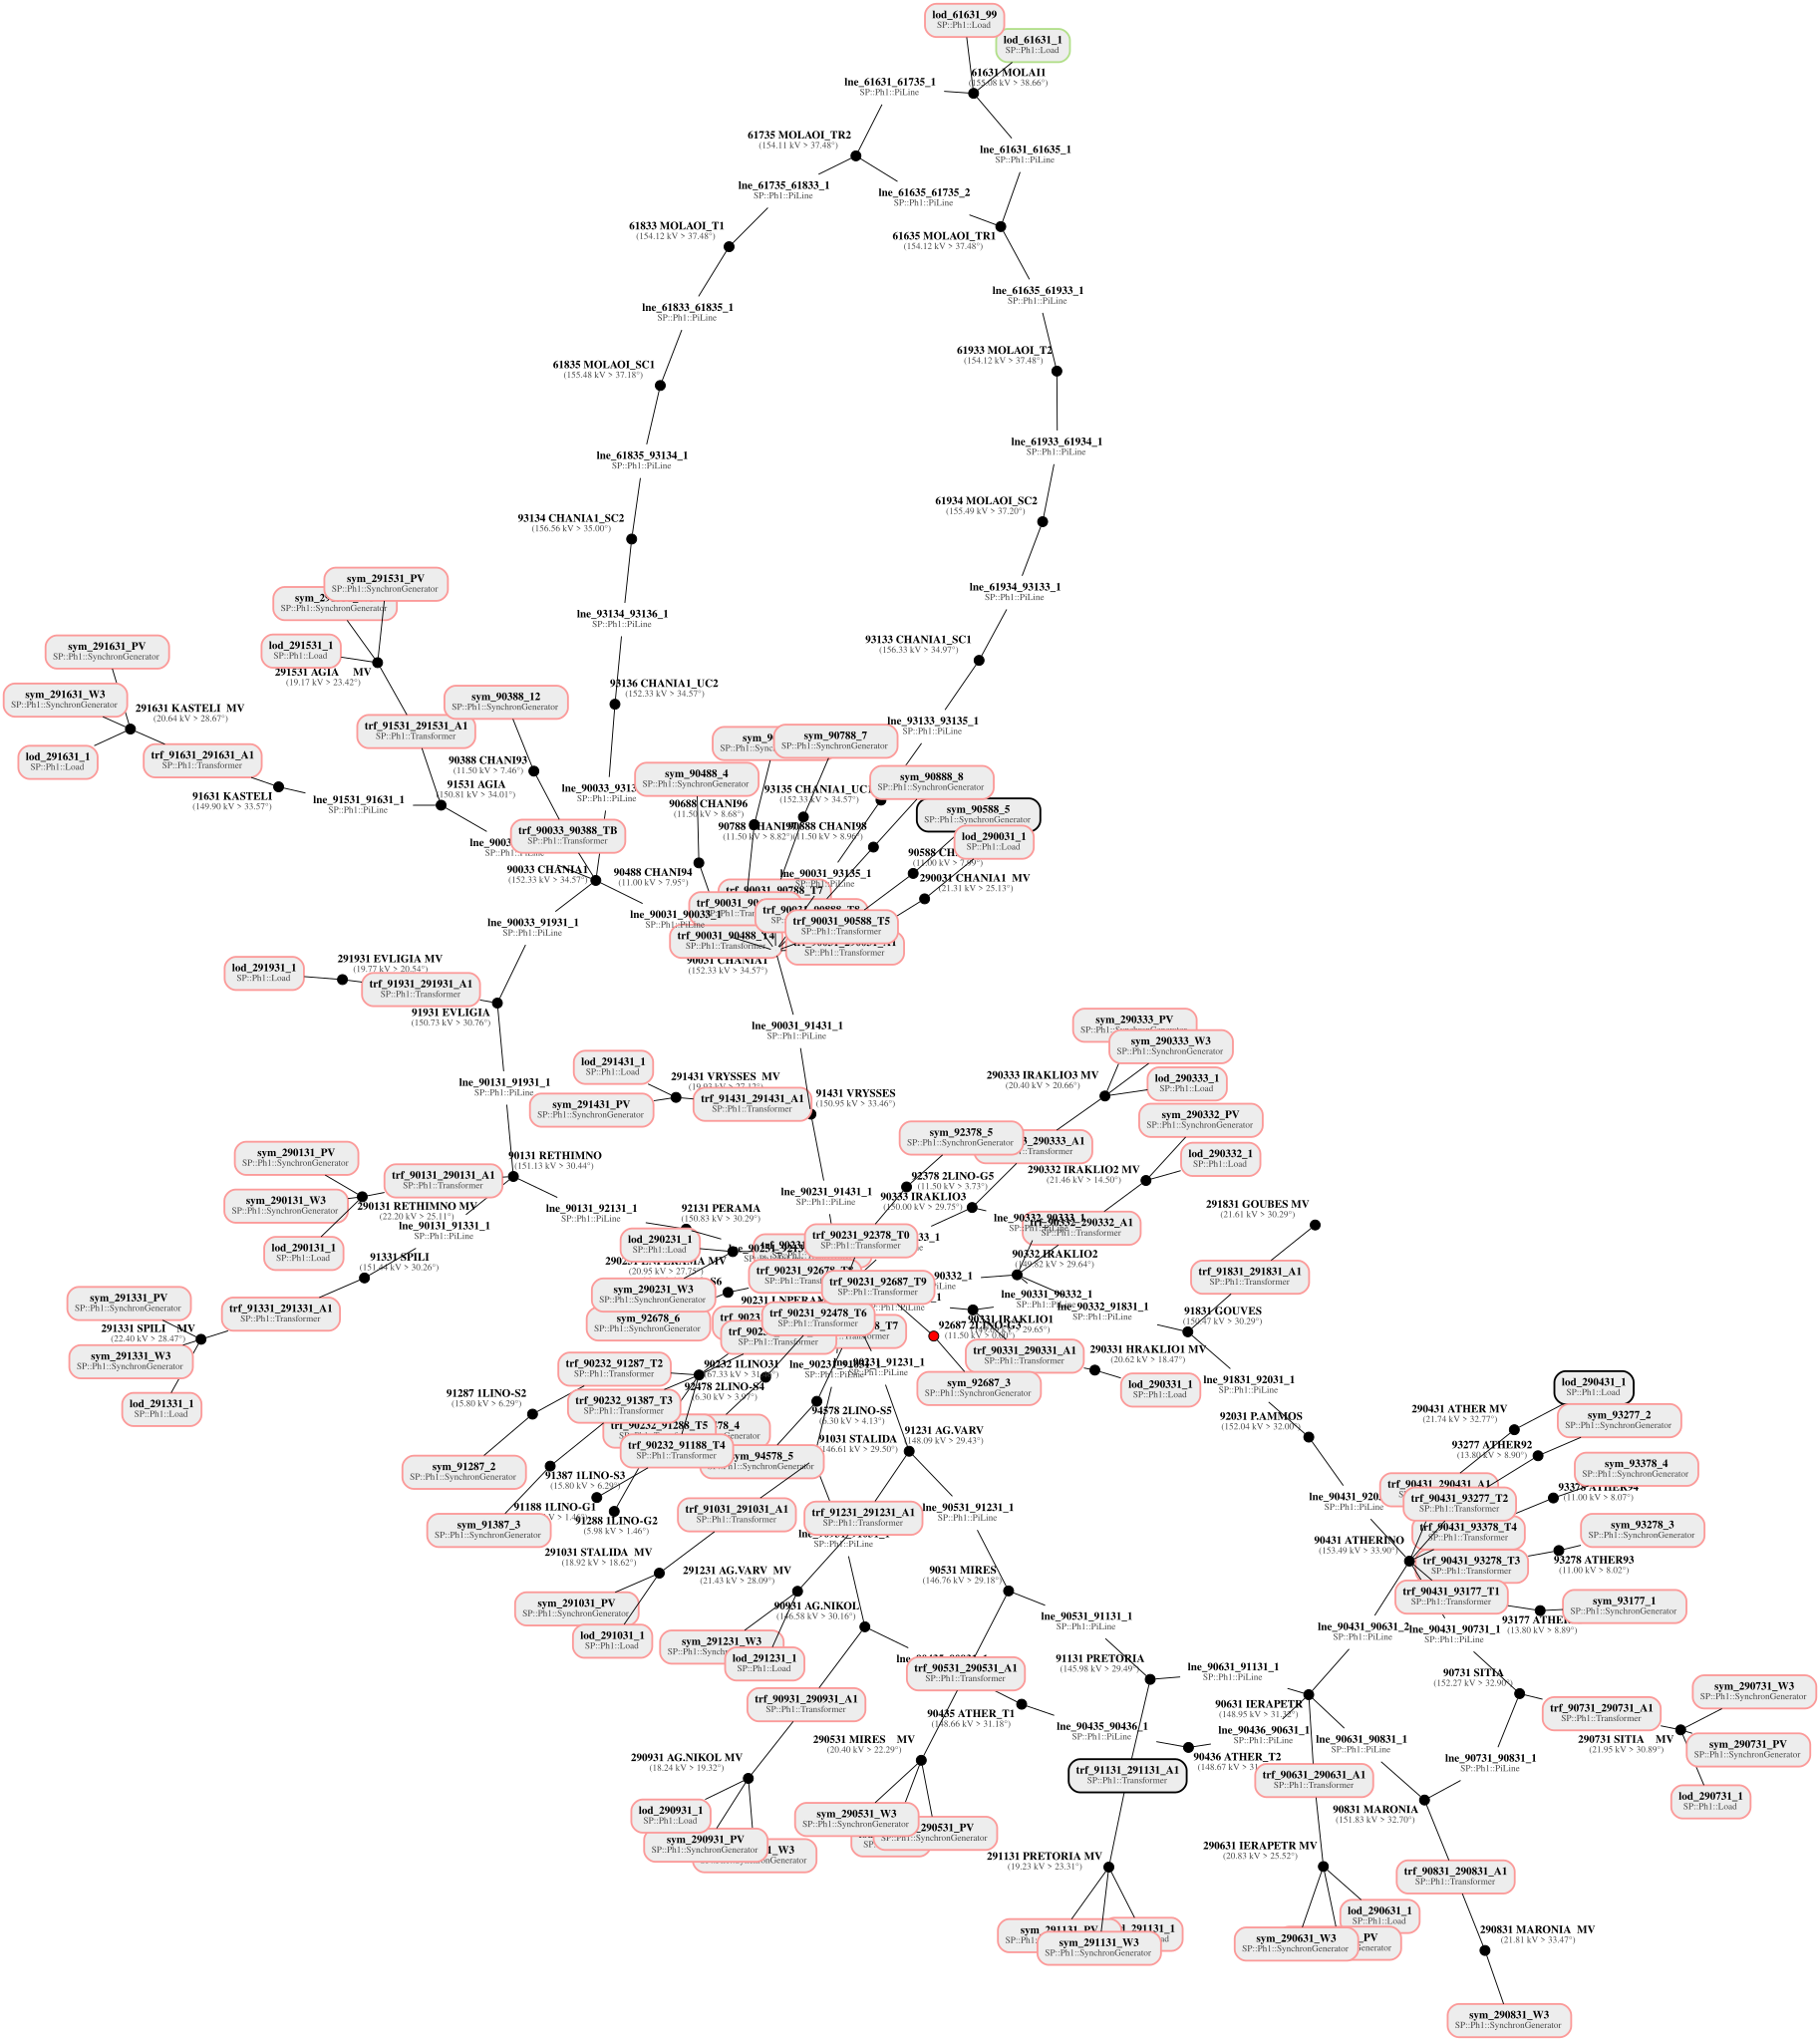

In [9]:
system

In [10]:
sim = dpsimpy.Simulation(name)
sim.set_system(system)
sim.set_domain(dpsimpy.Domain.SP)
sim.set_solver(dpsimpy.Solver.NRP)
sim.set_time_step(1)
sim.set_final_time(2)

logger = dpsimpy.Logger(name)
for node in system.nodes:
    logger.log_attribute(node.name()+'.V', 'v', node);
sim.add_logger(logger)

In [ ]:
sim.run()